
# Oscilador armónico y diferencias finitas para el calor

# Implementación guiada

**Módulo 5 — EDOs de orden superior y EDPs**

**Programación Científica 2026-1 · Universidad Nacional de Colombia**
mbastidaso@unal.edu.co

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)


In [1]:

# -- Instalacion de LaTeX para renderizado tipografico (descomentar en Colab) --
#!sudo apt-get update -qq
#!sudo apt-get install -qq texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np                              # arreglos y algebra lineal basica
import matplotlib.pyplot as plt                 # graficas
from scipy.sparse import diags                  # matrices tridiagonales dispersas (Parte 2)
from scipy.integrate import solve_ivp            # integrador adaptativo (Parte 2)

# -- Configuracion global de estilo matplotlib (igual que en clases anteriores) --
plt.rcParams.update({
    "text.usetex"        : True,                # usar LaTeX real para el texto
    "font.family"        : "serif",              # tipografia serif
    "font.serif"         : ["Computer Modern Roman"],  # Computer Modern, igual que en LaTeX
    "font.size"           : 14,                   # tamano de fuente base

    "axes.labelsize"      : 16,                   # tamano de las etiquetas de los ejes
    "axes.titlesize"      : 18,                   # tamano del titulo de la figura
    "xtick.labelsize"     : 12,                   # tamano de los numeros en el eje x
    "ytick.labelsize"     : 12,                   # tamano de los numeros en el eje y
    "legend.fontsize"     : 12,                   # tamano de la leyenda

    "figure.figsize"      : (7, 4.5),             # tamano por defecto de las figuras
    "axes.grid"           : True,                 # rejilla activada por defecto
    "grid.alpha"          : 0.3,                  # rejilla tenue, no compite con los datos
})

print("Configuracion cargada")

Configuracion cargada



---
# Parte 1 — Oscilador armónico

## La reducción de orden

El oscilador armónico simple es la EDO de orden 2
$$
\ddot y + \omega^2 y = 0, \qquad y(0)=y_0,\quad \dot y(0)=v_0.
$$

Con el estado $u=(u_1,u_2)=(y,\dot y)$, la forma companera es
$$
\dot u_1 = u_2, \qquad \dot u_2 = -\omega^2 u_1.
$$

In [ ]:
def oscilador_rhs(t, x, omega):

    # Lado derecho del oscilador armonico reducido a sistema de primer orden.
    # x[0] = y (posicion), x[1] = dy/dt (velocidad).
    # Devuelve [dy/dt, d2y/dt2], en ese orden, para que el solver lo use como dx/dt.

    y, dy = x                     # desempaquetamos el vector de estado
    ...           # ecuacion original despejada: y'' = -omega^2 * y

    return np.array([?, ?])    # [du1/dt, du2/dt] = [y', y'']

print("oscilador_rhs definida")


oscilador_rhs definida



Para $\ddot y + \omega^2 y = 0$ conocemos la solución exacta,
$$
y(t) = y_0\cos(\omega t) + \frac{v_0}{\omega}\sin(\omega t),
$$
así que podemos medir el error.


In [ ]:

# -- Parametros fisicos y condicion inicial --------------------------------
omega = 2.0                        # frecuencia angular del oscilador
y0, v0 = 1.0, 0.0                  # posicion y velocidad iniciales
x0 = np.array([y0, v0])            # vector de estado inicial u(0) = (y0, v0)

T = (0.0, 10.0)                    # tiempo final de la simulacion

sol = solve_ivp(oscilador_rhs, T, y0=x0, args=(omega,), method="RK45")

# ¿Se ve bien la solución? Más resolución en el tiempo, para ver mejor la comparación con la solución exacta:
t_eval=np.linspace(0, 10, 100)
#sol = solve_ivp(oscilador_rhs, T, t_eval=t_eval, y0=x0, args=(omega,), method="RK45")

times = sol.t
y = sol.y[0]  # extraemos la posicion y(t) de la solucion

# -- Solucion exacta, evaluada en los mismos tiempos ------------------------
y_exacta = y0 * np.cos(omega * t_eval) + (v0 / omega) * np.sin(omega * t_eval)

# -- Comparacion ------------------------------------------------------------
error_max = np.max(np.abs(y - y_exacta))     # error maximo punto a punto

# Proponga otra forma de calcular el error

print(f"Error maximo RK4 vs. solucion exacta: {error_max:.3e}")


ValueError: operands could not be broadcast together with shapes (26,) (100,) 

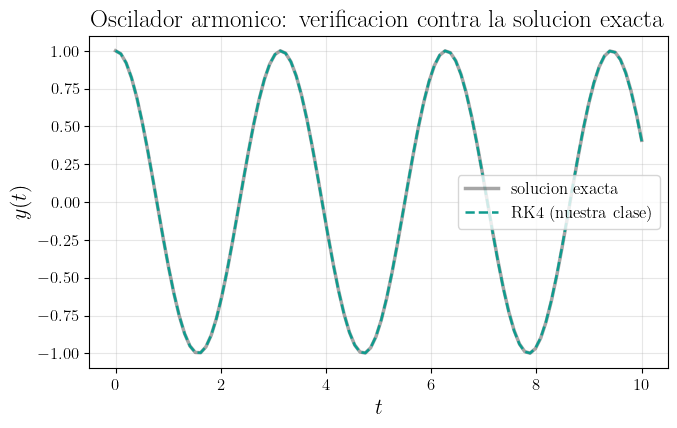

In [ ]:
fig, ax = plt.subplots()   
                                           # una figura, un eje
ax.plot(t_eval, y_exacta, color="k", lw=2.5, alpha=0.35,
        label="solucion exacta")                                       # curva de referencia
ax.plot(times, y, "--", color="#0F9B8E", lw=1.8,
        label="RK4 (nuestra clase)")                                   # curva numerica

ax.set_xlabel(r"$t$")                                                  # etiqueta eje x
ax.set_ylabel(r"$y(t)$")                                               # etiqueta eje y
ax.set_title("Oscilador armonico: verificacion contra la solucion exacta")  # titulo
ax.legend()                                                            # muestra la leyenda

plt.tight_layout()                                                     # ajusta margenes
plt.show()                                                             # despliega la figura



---
# Parte 2 — Diferencias finitas para la ecuación del calor (guiado)

## Recordando la semidiscretización

La ecuación del calor en 1D,
$$
\frac{\partial u}{\partial t} = \alpha\,\frac{\partial^2 u}{\partial x^2}, \qquad x\in[0,L],
$$
con frontera de Dirichlet homogénea $u(0,t)=u(L,t)=0$, se discretiza en
espacio reemplazando $\partial^2 u/\partial x^2$ por la segunda
diferencia central:
$$
u_i''\ \approx\ \frac{u_{i+1}-2u_i+u_{i-1}}{\Delta x^2}.
$$

Esto convierte la EDP en el sistema de EDOs **lineal**
$$
\dot u = \frac{\alpha}{\Delta x^2}\,A\,u, \qquad
A = \begin{pmatrix} -2&1& \\ 1&-2&1 \\ &\ddots&\ddots&\ddots \\ & &1&-2\end{pmatrix},
$$
donde $u(t)\in\mathbb{R}^N$ es el vector de valores en los $N$ nodos
interiores de la malla.

In [ ]:

def construir_matriz_laplaciano(N, dx):

    # Construye la matriz tridiagonal de segunda diferencia central,
    # para condiciones de frontera de Dirichlet homogeneas (u=0 en los bordes).
    # Devuelve una matriz dispersa N x N.
    # diagonales: -2 en la principal, 1 en las dos vecinas

    A = diags([1, -2, 1], [-1, 0, 1], shape=(N, N)) / dx**2   # dividido por dx^2 (formula de FD)
    return A                                                   # matriz lista para usar en el RHS


def calor_rhs(t, u, alpha, A):

    # Lado derecho del sistema semidiscretizado du/dt = alpha * A @ u.
    # Firma f(t, u, ...) porque asi lo exige solve_ivp (tiempo primero).
    return ...          # producto matriz-vector: du/dt en cada nodo


print("construir_matriz_laplaciano y calor_rhs definidas")


construir_matriz_laplaciano y calor_rhs definidas



## Resolviendo con `solve_ivp` y validando

Usamos como condición inicial $u_0(x)=\sin(\pi x/L)$: con Dirichlet
homogéneo, la solución exacta es conocida,
$$
u(x,t) = \sin(\pi x/L)\,e^{-\alpha(\pi/L)^2 t}.
$$


In [ ]:

# -- Malla espacial ----------------------------------------------------------
N = 100                                        # numero de nodos interiores
L, alpha = 1.0, 1.0                            # longitud del dominio y difusividad
dx = L / (N + 1)                               # paso espacial
x_completo = np.linspace(0, L, N + 2)          # incluye los dos puntos de frontera
x = x_completo[1:-1]                           # nodos interiores x_1,...,x_N

# -- Matriz de segunda diferencia --------------------------------------------
A = construir_matriz_laplaciano(N, dx)         # matriz tridiagonal N x N

# -- Condicion inicial y malla temporal ---------------------------------------
u0 = np.sin(np.pi * x / L)                     # condicion inicial (modo propio puro)
t_span = (0.0, 0.5)                            # intervalo de integracion
t_eval = np.linspace(*t_span, 200)             # tiempos donde queremos la solucion

# -- Integracion con solve_ivp -------------------------------------------------
sol = solve_ivp(...)

# -- Solucion exacta, para comparar --------------------------------------------
def solucion_exacta_calor(x, t, L, alpha):
    return np.sin(np.pi * x / L) * np.exp(-alpha * (np.pi / L)**2 * t)  # formula cerrada

errores = ...

print(f"Error maximo (todo el espacio-tiempo): {max(errores):.3e}")


Error maximo (todo el espacio-tiempo): 2.966e-05


ValueError: x and y must have same first dimension, but have shapes (100,) and (2,)

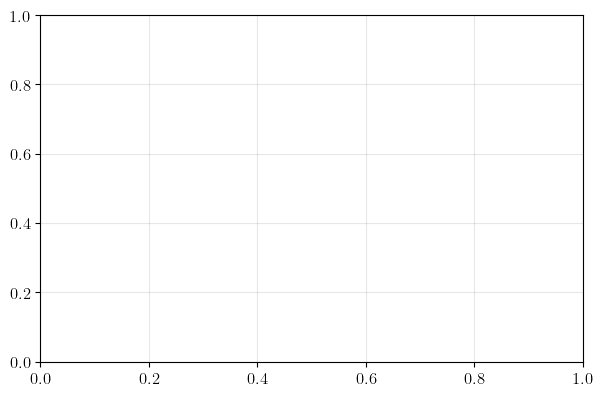

In [ ]:
fig, ax = plt.subplots()                                     # una figura, un eje

tiempos_mostrar = [0, 0.02, 0.05, 0.1, 0.2, 0.5]             # instantes que vamos a graficar
colores = plt.cm.viridis(np.linspace(0, 1, len(tiempos_mostrar)))  # paleta ordenada en el tiempo

for t_k, color in zip(tiempos_mostrar, colores):              # un perfil por instante
    
    idx = np.argmin(np.abs(sol.t - t_k))                      # indice del tiempo mas cercano

    ax.plot(x, sol.y[:, idx], color=color, lw=1.8,
            label=fr"$t={sol.t[idx]:.2f}$")                   # perfil numerico

ax.set_xlabel(r"$x$")                                          # etiqueta eje x
ax.set_ylabel(r"$u(x,t)$")                                     # etiqueta eje y
ax.set_title("Difusion del calor") 
ax.legend()                                        
plt.tight_layout()                                             # ajusta margenes
plt.show()                                                     # despliega la figura



### Ejercicio guiado — otra condición inicial

1. Definir una nueva condición inicial `u0_pulso`, un pulso rectangular:
   $u_0(x) = 1$ si $0.4 \le x \le 0.6$, y $0$ en el resto.
2. Resolver de nuevo con `solve_ivp`, usando la **misma** matriz `A`, el
   mismo `t_span` y `t_eval` que ya definimos.
3. Encontrar el primer tiempo `t_mitad` en el que el valor máximo de
   `u(x,t)` cae a la mitad de su valor máximo inicial (es decir, el
   primer índice donde `sol_pulso.y.max(axis=0) <= 0.5`).
4. Imprimir `t_mitad`.


In [ ]:

# TODO: complete el ejercicio guiado siguiendo los 4 pasos del enunciado.
#
# Pista de la forma que debe tener el codigo (descomente y complete):
#
# u0_pulso = ((x >= 0.4) & (x <= 0.6)).astype(float)
# sol_pulso = solve_ivp(calor_rhs, t_span, u0_pulso, args=(alpha, A),
#                        method="RK45", t_eval=t_eval, rtol=1e-8, atol=1e-10)
# maximos = sol_pulso.y.max(axis=0)          # maximo espacial en cada instante guardado
# idx_mitad = np.argmax(maximos <= 0.5 * maximos[0])   # primer indice que cumple la condicion
# t_mitad = sol_pulso.t[idx_mitad]
#
# print(f"t donde el maximo cae a la mitad: {t_mitad:.4f}")
